In [1]:

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
X, y = fetch_openml(name = "Boston", version = 1, as_frame=False, return_X_y= True)
X = X.astype(np.float32)
y = y.astype(np.float32)

In [3]:
# Train / test split and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

model.compile(optimizer= keras.optimizers.Adam(learning_rate=0.01), loss = 'mse',metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_train, y_train, validation_split = 0.1, epochs = 100, batch_size = 32, verbose = 0)

In [6]:
mse , mae = model.evaluate(X_test, y_test, verbose=0)
mse, mae

(12.005301475524902, 2.3282132148742676)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


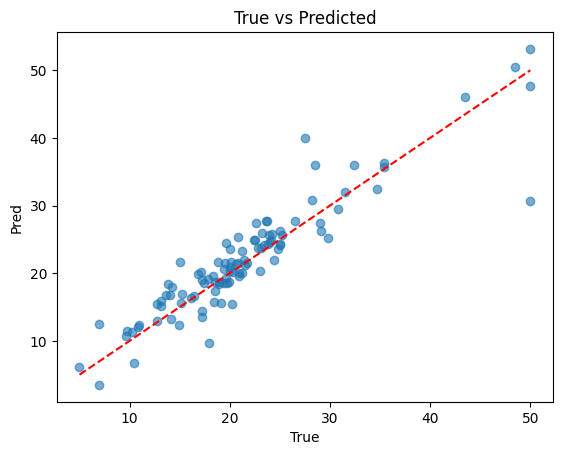

In [7]:
import matplotlib.pyplot as plt
y_pred = model.predict(X_test).flatten()
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True')
plt.ylabel('Pred')
plt.title('True vs Predicted')
plt.show()